In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
class PatchMaskWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, patch_size=8, mask_ratio=0.5):
        self.dataset = dataset
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]  # img: (C, H, W)

        C, H, W = img.shape
        p = self.patch_size

        # Number of patches
        num_h = H // p                # = 96 / 8
        num_w = W // p
        num_patches = num_h * num_w   # = 12 * 12

        # Randomly select which patches to mask
        # torch.randperm(num_patches) 會產生 0 ~ num_patches‑1 的隨機排列
        # 例如 num_patches = 12 時，可能得到 [5, 2, 11, 0, 8, 3, 9, 1, 6, 10, 4, 7]
        num_mask = int(self.mask_ratio * num_patches)  # = 9 * 12
        mask_idx = torch.randperm(num_patches)[:num_mask]

        # create boolean mask (1 = visible, 0 = masked)
        mask = torch.ones(num_patches)
        mask[mask_idx] = 0
        mask = mask.reshape(num_h, num_w)

        # Expand mask to pixel space
        mask_pixels = mask.repeat_interleave(p, 0).repeat_interleave(p, 1)  # (H, W)
        mask_pixels = mask_pixels.unsqueeze(0)  # (1, H, W)

        # masked input
        img_masked = img * mask_pixels

        return img_masked, img, mask_pixels

In [3]:
from torchvision import datasets, transforms

dataset = datasets.STL10(root='./data', split='train', download=True,
                         transform=transforms.ToTensor())

masked_dataset = PatchMaskWrapper(dataset, patch_size=8, mask_ratio=0.5)
loader = torch.utils.data.DataLoader(masked_dataset, batch_size=32, shuffle=True)

100%|██████████| 2.64G/2.64G [02:31<00:00, 17.5MB/s]


## 1.1：Iterative SVD（Project Gradient Descent）矩陣補全函式

In [5]:
import torch

def svt_matrix_completion(M_obs, mask,
                          num_iters=100, eta=1.0, tau=0.2, device="cpu"):
    """
    M_obs : observed matrix (H, W)
    mask  : 1 for observed, 0 for missing (H, W)
    eta   : gradient step size
    tau   : soft-threshold parameter
    """

    X = M_obs.clone().to(device)
    mask = mask.to(device)
    M_obs = M_obs.to(device)

    losses = []  # 新增: 記錄 loss
    ranks = []

    for t in range(num_iters):
        # Gradient step
        grad = mask * (X - M_obs)

        # PGD step: Y = X - eta * grad
        Y = X - eta * grad

        # SVD — usually on CPU (faster & stable for medium-sized matrices)
        U, S, Vh = torch.linalg.svd(Y.cpu(), full_matrices=False)

        # Soft-thresholding (nuclear norm projection)
        S_thresh = torch.clamp(S - tau, min=0)

        # Reconstruct
        X = (U * S_thresh) @ Vh
        X = X.to(device)
        ranks.append(torch.linalg.matrix_rank(X))

        # 計算正確的 objective loss:
        # Loss = 0.5 * || P_omega(X - M) ||_F^2 + (tau / eta) * || X ||_*
        # 1. Reconstruction (Fidelity) Loss
        rec_loss = 0.5 * (torch.norm(mask * (X - M_obs)) ** 2).item()

        # 2. Nuclear Norm Regularization (sum of singular values)
        # S_thresh 已經是 X 的 singular values
        nuc_loss = (tau / eta) * torch.sum(S_thresh).item()

        losses.append(rec_loss + nuc_loss)

    return X, losses, ranks


def reconstruct_rgb(masked_img, mask_pixels, num_iters=80, tau=0.1):
    C, H, W = masked_img.shape
    #H, W = masked_img.shape
    out = torch.zeros_like(masked_img)

    channel_losses = [] # 新增
    channel_ranks = []

    for c in range(C):  # per-channel PGD
        M_obs = masked_img[c]
        # 修改: 接收回傳的 loss
        completed, losses, rank = svt_matrix_completion(
            M_obs=M_obs,
            mask=mask_pixels,
            num_iters=num_iters,
            tau=tau
        )
        out[c] = completed
        channel_losses.append(losses[1:]) # 記錄每一個channel loss history
        channel_ranks.append(rank)

    # avg_loss = np.mean(channel_losses, axis=0)

    return out.clamp(0, 1), channel_losses, channel_ranks # 新增: 回傳平均 loss

# 1.2 Masked AutoEncoder

## Step 2：Plot Result

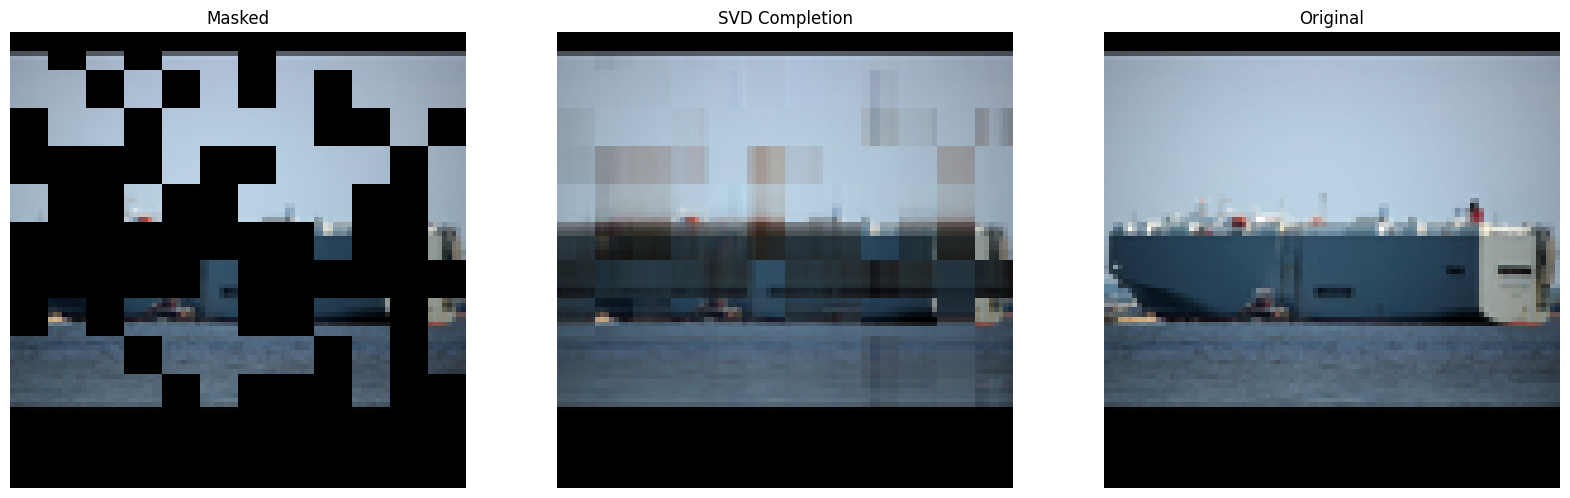

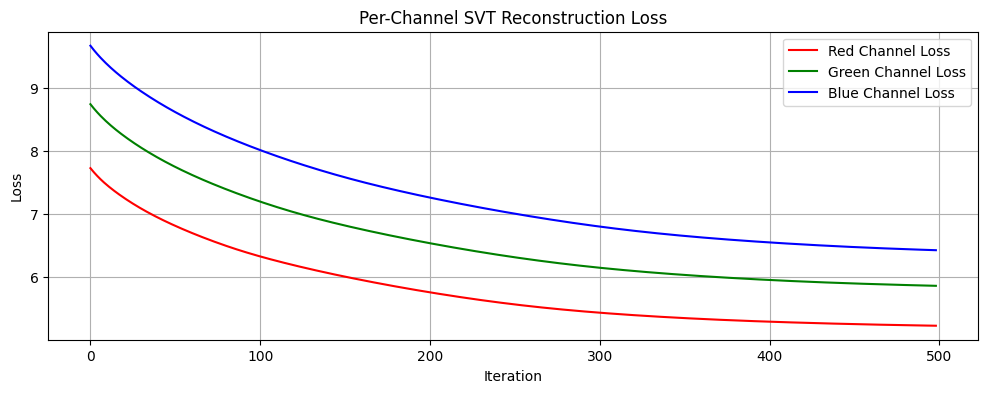

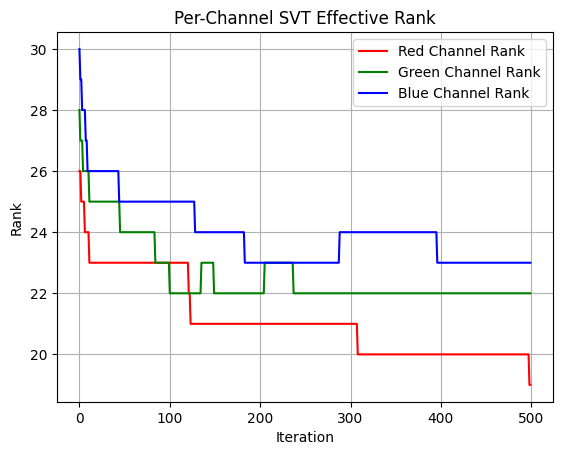

In [52]:
# 執行補全並獲取 loss
torch.manual_seed(42)
data_iter = iter(loader)

k = 18   # 想要第 5 個 batch
for _ in range(k):
    next(data_iter)

masked_batch, img_batch, mask_batch = next(data_iter)

# 因為現在 batch_size > 1，我們只取第一張圖來做 SVT 演示
masked_img = masked_batch[0]       # (C, H, W)
img = img_batch[0]                 # (C, H, W)
mask_pixels = mask_batch[0]        # (1, H, W) 或 (C, H, W)

# 確保 mask 是 (H, W) or (1, H, W)，SVT 函數內會處理 broadcasting
if mask_pixels.dim() == 3 and mask_pixels.shape[0] == 1:
    mask_pixels = mask_pixels.squeeze(0)  # (H, W)

origin_img_rank = torch.linalg.matrix_rank(img)

reconstruct, loss_history, channel_ranks = reconstruct_rgb(masked_img, mask_pixels,
                                                           num_iters=500, tau=0.1)


# Plot
fig, axs = plt.subplots(1, 3, figsize=(20,8))

images = [
    (masked_img, "Masked"),
    (reconstruct, "SVD Completion"),
    (img, "Original"),
]

for ax, (im, title) in zip(axs, images):
    im = im.permute(1,2,0).detach().cpu().numpy()
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

colors = ["r", "g", "b"]
labels = ["Red Channel Loss", "Green Channel Loss", "Blue Channel Loss"]

for loss, color, label in zip(loss_history, colors, labels):
    plt.plot(loss, color, label=label)

plt.title("Per-Channel SVT Reconstruction Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

labels = ["Red Channel Rank", "Green Channel Rank", "Blue Channel Rank"]
for rank, color, label in zip(channel_ranks, colors, labels):
    plt.plot(rank, color, label=label)

plt.title("Per-Channel SVT Effective Rank")
plt.xlabel("Iteration")
plt.ylabel("Rank")
#plt.axvline(origin_img_rank, color="r", linestyle="--", label="effective rank ≈ 96")

plt.legend()
plt.grid(True)
plt.show()

In [7]:
import torch.nn as nn

class ResNetBlock(nn.Module):
    """
    基本的 ResNet Block，幫助梯度傳遞，讓網路可以疊更深
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out

class MaskedAutoencoderCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        # Encoder
        # 改良點 1: Input channel + 1，因為我們要 concatenate mask
        # 這樣模型才能區分「原本是黑色」跟「被 Mask 掉」的區域
        self.init_conv = nn.Sequential(
            nn.Conv2d(in_channels + 1, 64, kernel_size=7, padding=3, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        ) # Output: 96x96

        # 下採样 1: 96 -> 48
        self.encoder1 = nn.Sequential(
             nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2, bias=False),
             nn.BatchNorm2d(128),
             nn.ReLU(inplace=True),
             ResNetBlock(128) # 加深網路
        )

        # 下採样 2: 48 -> 24
        self.encoder2 = nn.Sequential(
             nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2, bias=False),
             nn.BatchNorm2d(256),
             nn.ReLU(inplace=True),
             ResNetBlock(256)
        )

        # 下採样 3: 24 -> 12
        self.encoder3 = nn.Sequential(
             nn.Conv2d(256, 512, kernel_size=3, padding=1, stride=2, bias=False),
             nn.BatchNorm2d(512),
             nn.ReLU(inplace=True),
             ResNetBlock(512)
        )

        # Bottleneck: 12x12x512

        # Decoder
        # 上採樣 1: 12 -> 24
        self.decoder3 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, padding=1, output_padding=1, stride=2, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            ResNetBlock(256)
        )

        # 上採樣 2: 24 -> 48
        self.decoder2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, padding=1, output_padding=1, stride=2, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResNetBlock(128)
        )

        # 上採樣 3: 48 -> 96
        self.decoder1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1, output_padding=1, stride=2, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResNetBlock(64)
        )

        # Output Layer
        self.final_conv = nn.Conv2d(64, in_channels, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, mask=None):
        """
        x: (B, 3, H, W) - 已經被 mask 蓋住的圖片 (masked regions should be 0)
        mask: (B, 1, H, W) - 0 表示被 mask (missing), 1 表示正常 (visible)
              或者是反過來，重點是提供位置資訊。
              建議: 1 for valid pixels, 0 for missing pixels.
        """

        # 如果沒有傳入 mask，就假設一個全 1 的 mask (雖然這樣就失去 MAE 意義，但保持相容性)
        if mask is None:
            B, C, H, W = x.shape
            mask = torch.ones((B, 1, H, W), device=x.device)

        # Concatenate mask to input
        # input shape 變成 (B, 4, H, W)
        x_in = torch.cat([x, mask], dim=1)

        f0 = self.init_conv(x_in) # 64, 96, 96
        f1 = self.encoder1(f0)    # 128, 48, 48
        f2 = self.encoder2(f1)    # 256, 24, 24
        f3 = self.encoder3(f2)    # 512, 12, 12

        d3 = self.decoder3(f3)    # 256, 24, 24
        d2 = self.decoder2(d3)    # 128, 48, 48
        d1 = self.decoder1(d2)    # 64, 96, 96

        out = self.final_conv(d1)
        return self.sigmoid(out)

In [8]:
def masked_reconstruction_loss(pred, target, mask_pixels):
    """
    pred, target: (B, 3, H, W)
    mask_pixels : (B, 1, H, W), 1 = visible, 0 = masked
    """
    # 1. Masked Loss ( Reconstruction on missing pixels )
    miss_mask = 1.0 - mask_pixels
    n_miss = miss_mask.sum()

    # 使用 MSE (sum) 再除以數量
    # 分母 clamp(min=1.0) 避免 divide by zero error (因為 pixel 數量通常 >=1，如果是 0 則 loss 分子也為 0)
    loss_mask = F.mse_loss(pred * miss_mask, target * miss_mask, reduction='sum') / n_miss.clamp(min=1.0)

    # 2. Valid Loss ( Consistency on visible pixels )
    valid_mask = mask_pixels
    n_valid = valid_mask.sum()

    loss_valid = F.mse_loss(pred * valid_mask, target * valid_mask, reduction='sum') / n_valid.clamp(min=1.0)

    return loss_mask + 0.1 * loss_valid

In [33]:
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
# -----------------------------
# 1. 建立 model / optimizer / scheduler
# -----------------------------
def build_mae_and_scheduler(total_epochs):
    mae = MaskedAutoencoderCNN(in_channels=3).to(device)
    optimizer = torch.optim.Adam(mae.parameters(), lr=1e-3)

    warmup_epochs = 5
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1e-3, end_factor=1.0, total_iters=warmup_epochs
    )

    # 修正: T_max 至少要為 1，避免 total_epochs <= warmup_epochs 時除以零
    # 這裡 total_epochs - warmup_epochs 如果是 0，T_max 就會是 0 -> Error
    T_max = max(1, total_epochs - warmup_epochs)

    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=T_max, eta_min=1e-5
    )

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[warmup_epochs],
    )
    return mae, optimizer, scheduler


# -----------------------------
# 2. 嘗試讀 checkpoint（自動偵測）
# -----------------------------
ckpt_path = "checkpoint_mae3.pth"
total_epochs = 20  # 增加訓練次數，MAE 需要較多 epochs (建議 100+, 測試用 20)

# 新增：用來記錄每個 batch 的 loss（每個 epoch 內的細節）
batch_loss_history = []  # List of lists, 每個子 list 為該 epoch 的 batch loss

mae, optimizer, scheduler = build_mae_and_scheduler(total_epochs)

if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=device)

    mae.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])

    start_epoch = checkpoint["epoch"]

    # 嘗試讀取 loss history，如果是舊版 checkpoint 沒有這個 key 則用空 list
    train_loss_history = checkpoint.get("loss_history", [])
    # 嘗試讀取 batch loss history（每個 epoch 的 batch 細節）
    batch_loss_history = checkpoint.get("batch_loss_history", [])

    print(f"✔ Found checkpoint → Resuming from epoch {start_epoch}")
else:
    start_epoch = 0
    train_loss_history = []
    print("✔ No checkpoint found → Starting training from scratch")


# -----------------------------
# 3. 單一訓練 loop（自動從 start_epoch 開始）
# -----------------------------
for epoch in range(start_epoch, start_epoch + total_epochs):
    mae.train()
    epoch_loss = 0.0
    # 暫存本 epoch 的 batch loss
    batch_losses = []

    for masked_img, img, mask_pixels in loader:
        masked_img = masked_img.to(device)
        img = img.to(device)
        mask_pixels = mask_pixels.to(device)

        optimizer.zero_grad()
        # 修正: 記得把 mask 傳進去！
        recon = mae(masked_img, mask_pixels)
        loss = masked_reconstruction_loss(recon, img, mask_pixels)
        loss.backward()
        optimizer.step()

        # 記錄此 batch 的 loss（scalar）
        batch_losses.append(loss.item())
        epoch_loss += loss.item()

    # 把本 epoch 的 batch loss 加入全局歷史
    batch_loss_history.append(batch_losses)
    scheduler.step()


    avg_loss = epoch_loss / len(loader)
    train_loss_history.append(avg_loss)  # 記錄 epoch 平均 loss
    print(f"Epoch {epoch+1}/{total_epochs}, loss = {avg_loss:.6f}")

    # ---- 每個 epoch 自動存 checkpoint ----
    torch.save({
        "epoch": epoch + 1,
        "model": mae.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "loss_history": train_loss_history,  # 儲存 epoch 平均 loss
        "batch_loss_history": batch_loss_history,  # 儲存每個 batch 的 loss
    }, ckpt_path)

print("🎉 Training completed.")

✔ Found checkpoint → Resuming from epoch 30
Epoch 31/20, loss = 0.036694
Epoch 32/20, loss = 0.036651
Epoch 33/20, loss = 0.038021
Epoch 34/20, loss = 0.039470
Epoch 35/20, loss = 0.040084
Epoch 36/20, loss = 0.040527
Epoch 37/20, loss = 0.039265
Epoch 38/20, loss = 0.038261
Epoch 39/20, loss = 0.036943
Epoch 40/20, loss = 0.035953
Epoch 41/20, loss = 0.035590
Epoch 42/20, loss = 0.035788
Epoch 43/20, loss = 0.036949
Epoch 44/20, loss = 0.037677
Epoch 45/20, loss = 0.039158
Epoch 46/20, loss = 0.040024
Epoch 47/20, loss = 0.038389
Epoch 48/20, loss = 0.036815
Epoch 49/20, loss = 0.035746
Epoch 50/20, loss = 0.034881
🎉 Training completed.


## Load model

In [34]:
ckpt_path = "checkpoint_mae3.pth"

# Step 1: 先建立 model / optimizer / scheduler
mae, optimizer, scheduler = build_mae_and_scheduler(total_epochs)
mae.to(device)

# Step 2: 讀檔案
checkpoint = torch.load(ckpt_path, map_location=device)

# Step 3: 載回模型參數
mae.load_state_dict(checkpoint["model"])

# Step 4: 載回 optimizer & scheduler 狀態
optimizer.load_state_dict(checkpoint["optimizer"])
scheduler.load_state_dict(checkpoint["scheduler"])

# Step 5: 從哪一個 epoch 繼續？
start_epoch = checkpoint["epoch"]

print(f"✔ Loaded checkpoint — resume from epoch {start_epoch}")

✔ Loaded checkpoint — resume from epoch 50


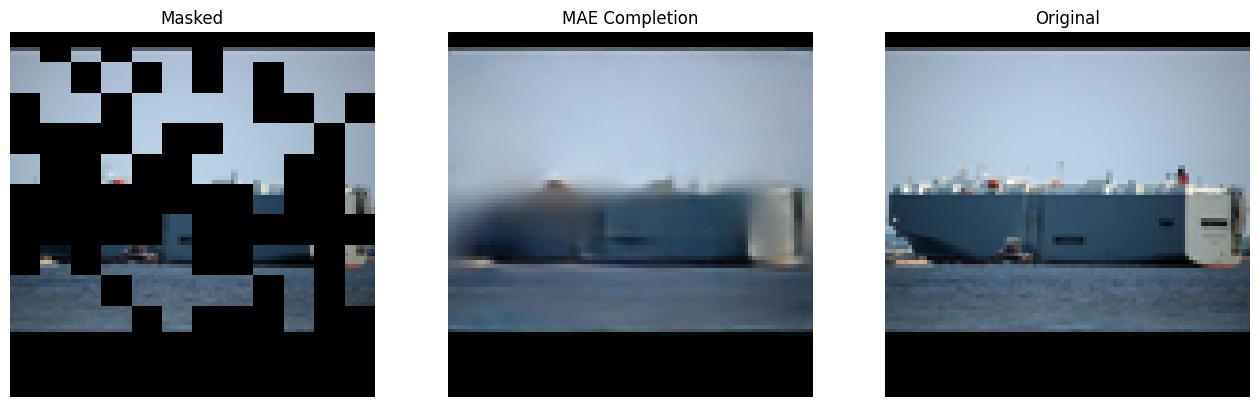

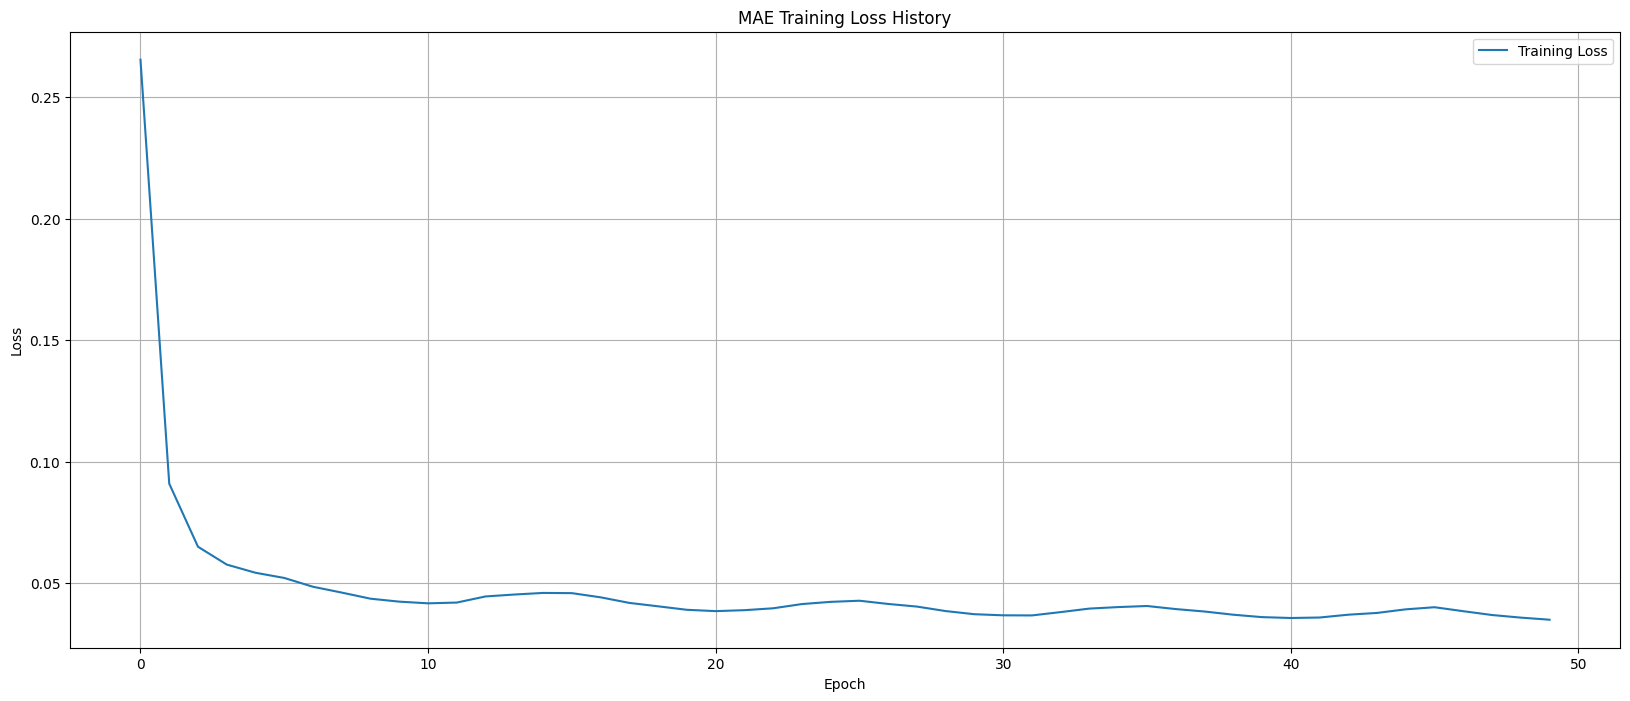

In [50]:
# 取同一張圖做比較
torch.manual_seed(42)
data_iter = iter(loader)
for _ in range(k):
    next(data_iter)
masked_img, img, mask_pixels = next(data_iter)

masked_img = masked_img.to(device)
img        = img.to(device)
mask_pixels = mask_pixels.to(device)

mae.eval()
with torch.no_grad():
    mae_recon = mae(masked_img, mask_pixels)  # (1,3,H,W)

# squeeze + 移到 CPU 繪圖
mi  = masked_img[0].cpu()
svt = reconstruct.cpu()          # 你前面 SVT 的結果 (3,H,W)
mr  = mae_recon[0].cpu()
ori = img[0].cpu()

fig, axs = plt.subplots(1, 3, figsize=(16,8))
titles = ["Masked", "MAE Completion", "Original"]
images = [mi, mr, ori]

for ax, im, title in zip(axs, images, titles):
    ax.imshow(im.permute(1,2,0).numpy())
    ax.set_title(title)
    ax.axis("off")

plt.show()

# Plot Loss History
if 'train_loss_history' in globals() and len(train_loss_history) > 0:
    plt.figure(figsize=(20, 8))
    plt.plot(train_loss_history, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MAE Training Loss History")
    plt.legend()
    plt.grid(True)
    plt.show()
elif os.path.exists(ckpt_path):
    # 如果是直接跑這段 code (沒有經過上面 train loop)，嘗試從 checkpoint 讀取
    try:
        checkpoint = torch.load(ckpt_path, map_location=device)
        hist = checkpoint.get("loss_history", [])
        if len(hist) > 0:
            plt.figure(figsize=(10, 5))
            plt.plot(hist, label="Training Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title("MAE Training Loss History")
            plt.legend()
            plt.grid(True)

    except:
        pass

## 1.3 實驗：低頻 vs 高頻圖片的補全效果比較 (SVT vs MAE)

我們這裡驗證一個假設：
- **Low Frequency (低頻/平滑)**：SVT (Low Rank) 應該效果很好，因為圖片結構簡單，Rank 較低。
- **High Frequency (高頻/紋理)**：SVT 可能會丟失細節（因為細節往往是 High Rank），而 MAE 因為有學過紋理特徵，可能表現較好（要在 Training Distribution 內）。

In [36]:
def calculate_image_complexity(img_tensor):
    """
    計算圖片的「複雜度」或「高頻程度」。
    這裡使用簡單的 Total Variation (TV) 概念：相鄰像素差異越大，頻率越高。
    img_tensor: (C, H, W)
    """
    # 計算水平方向梯度
    diff_h = torch.abs(img_tensor[:, :, :-1] - img_tensor[:, :, 1:])
    # 計算垂直方向梯度
    diff_v = torch.abs(img_tensor[:, :-1, :] - img_tensor[:, 1:, :])

    # 平均梯度大小
    score = (diff_h.mean() + diff_v.mean()).item()
    return score

# 掃描前 100 張圖片，找出「最低頻」與「最高頻」的代表
num_scan = 100
low_freq_idx = -1
high_freq_idx = -1
min_score = float('inf')
max_score = float('-inf')

dataset_scan = datasets.STL10(root='./data', split='train', download=True,
                              transform=transforms.ToTensor())

print(f"Scanning first {num_scan} images for frequency content...")

for i in range(num_scan):
    img, _ = dataset_scan[i]
    score = calculate_image_complexity(img)

    if score < min_score:
        min_score = score
        low_freq_idx = i

    if score > max_score:
        max_score = score
        high_freq_idx = i

print(f"Found Low Freq Image Index: {low_freq_idx} (Score: {min_score:.4f})")
print(f"Found High Freq Image Index: {high_freq_idx} (Score: {max_score:.4f})")

Scanning first 100 images for frequency content...
Found Low Freq Image Index: 31 (Score: 0.0204)
Found High Freq Image Index: 38 (Score: 0.2202)


In [37]:
# 準備實驗函數
def run_comparison(image_idx, title_prefix):
    # 1. 讀取圖片 & 製作 Mask
    orig_img, _ = dataset_scan[image_idx] # (C, H, W)

    # 建立一個臨時的 dataset wrapper 為了拿到一樣的 mask 邏輯
    # 這裡我們手動造 mask 比較方便，保證一致性
    C, H, W = orig_img.shape
    patch_size = 8
    mask_ratio = 50 / (12*12) # 約 35% masking

    num_h = H // patch_size
    num_w = W // patch_size
    num_patches = num_h * num_w
    num_mask = int(mask_ratio * num_patches)
    if num_mask == 0: num_mask = 30 # fallback

    # 固定隨機種子以確保重現
    g_cpu = torch.Generator()
    g_cpu.manual_seed(42)

    mask_idx = torch.randperm(num_patches, generator=g_cpu)[:num_mask]
    mask = torch.ones(num_patches)
    mask[mask_idx] = 0
    mask = mask.reshape(num_h, num_w)

    mask_pixels = mask.repeat_interleave(patch_size, 0).repeat_interleave(patch_size, 1) # (H, W)
    mask_pixels = mask_pixels.unsqueeze(0) # (1, H, W)

    masked_img = orig_img * mask_pixels

    # 2. SVT Recon (Iteration 500, tau 0.5)
    print(f"[{title_prefix}] Running SVT...")
    svt_recon, _, _ = reconstruct_rgb(masked_img, mask_pixels, num_iters=500, tau=0.5)

    # 3. MAE Recon
    print(f"[{title_prefix}] Running MAE...")
    mae.eval()
    with torch.no_grad():
        # MAE 需要 batch dimension
        mae_input = masked_img.unsqueeze(0).to(device)
        mask_input = mask_pixels.unsqueeze(0).to(device)
        mae_out = mae(mae_input, mask_input)
        mae_recon = mae_out[0].cpu()

    # 4. Visualization
    import numpy as np
    fig, axs = plt.subplots(1, 4, figsize=(16, 5))

    imgs = [masked_img, svt_recon, mae_recon, orig_img]
    titles = ["Masked Input", "SVT (Low Rank)", "MAE (Deep Learning)", "Original"]

    for ax, im, t in zip(axs, imgs, titles):
        im_np = im.permute(1, 2, 0).numpy()
        ax.imshow(np.clip(im_np, 0, 1))
        ax.set_title(t)
        ax.axis("off")

    plt.suptitle(f"{title_prefix} Frequency Image Comparison\nComplexity Score: {calculate_image_complexity(orig_img):.4f}")
    plt.tight_layout()
    plt.show()

[Low] Running SVT...
[Low] Running MAE...


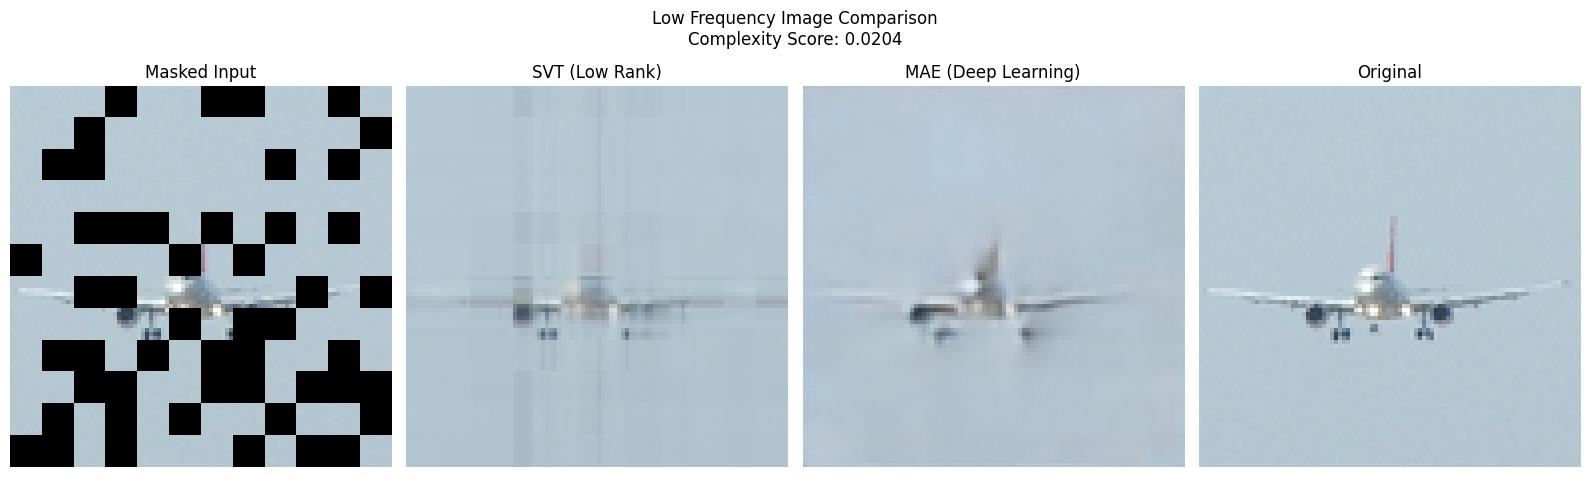

[High] Running SVT...
[High] Running MAE...


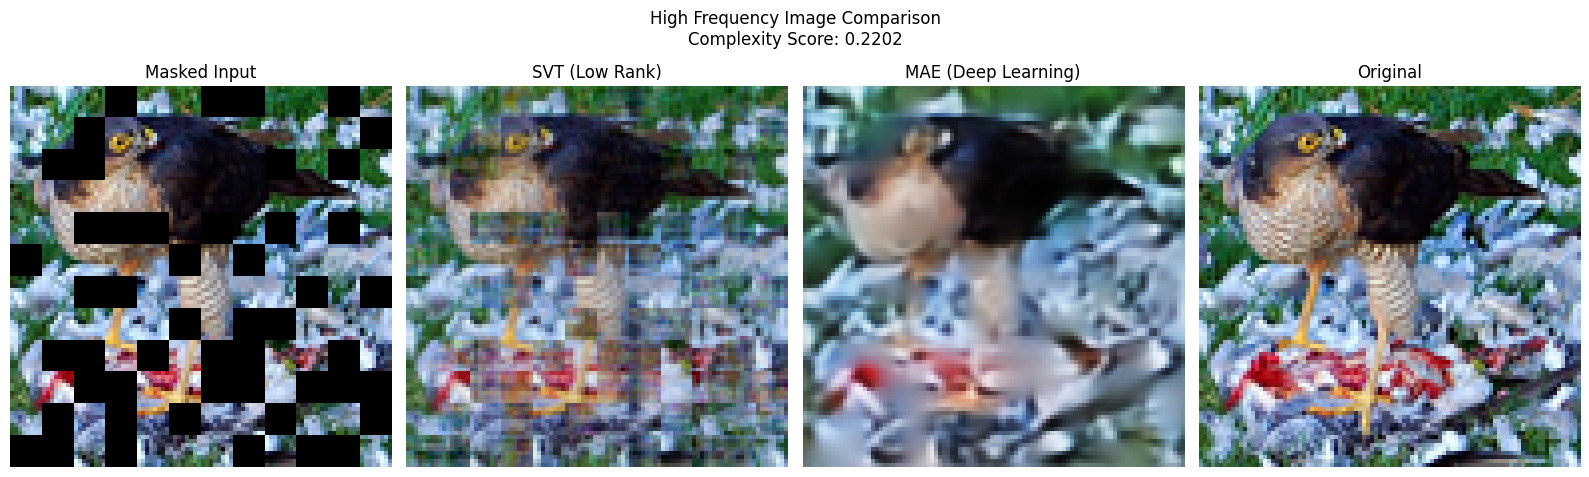

In [38]:
# 執行比較
# 確保 mae 有被定義 (如果直接跑這段的話)
if 'mae' not in globals():
    print("Initialize MAE model for inference...")
    mae, _, _ = build_mae_and_scheduler(1)
    if os.path.exists("checkpoint_MAE.pth"):
        ckpt = torch.load("checkpoint_MAE.pth", map_location=device)
        mae.load_state_dict(ckpt["model"])
        print("Loaded MAE checkpoint.")
    mae.to(device)

run_comparison(low_freq_idx, "Low")
run_comparison(high_freq_idx, "High")


Analyzing FFT Spectrums...


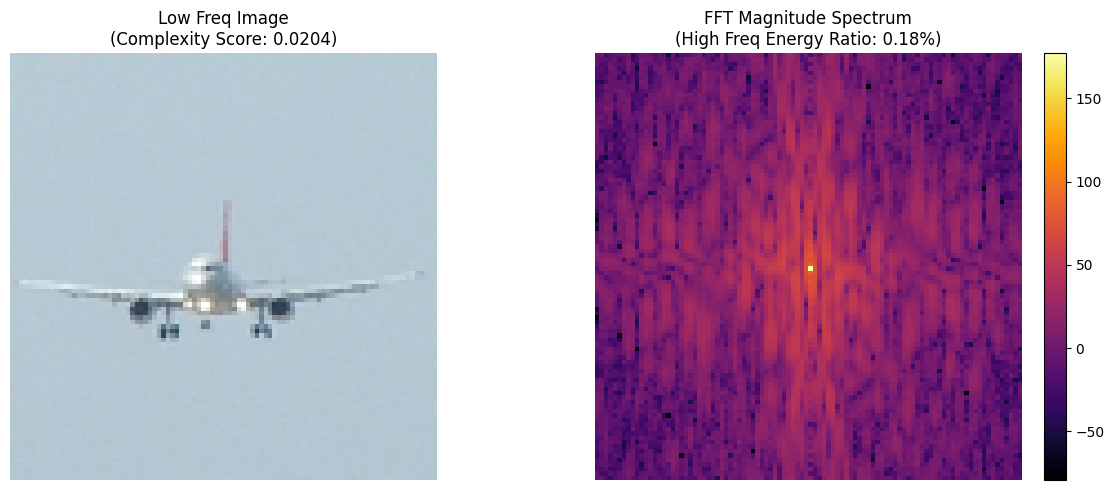

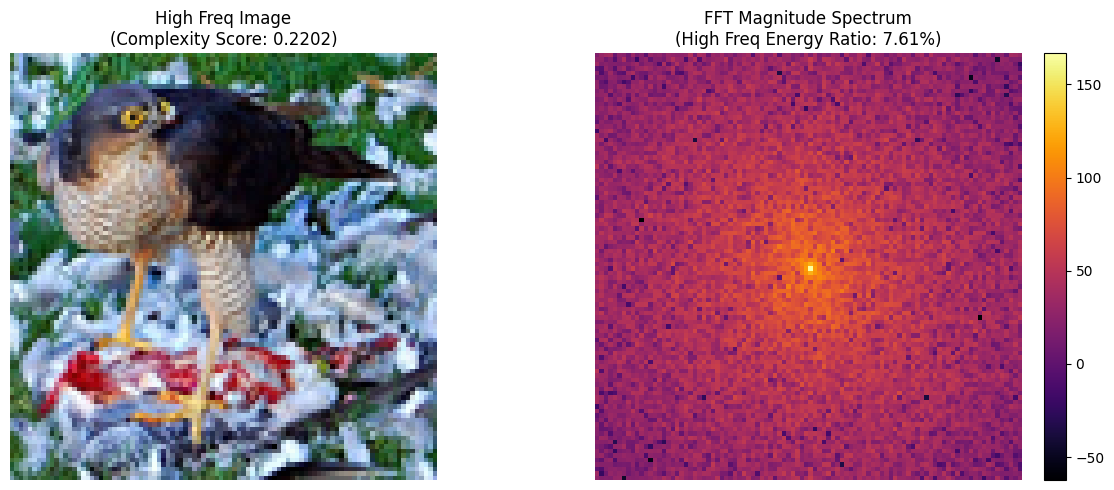

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_fft_spectrum(image_idx, title_prefix):
    img_tensor, _ = dataset_scan[image_idx] # (3, H, W)

    # 轉成灰階 (Grayscale) 方便做 2D FFT
    # Y = 0.299 R + 0.587 G + 0.114 B
    img_gray = 0.299 * img_tensor[0] + 0.587 * img_tensor[1] + 0.114 * img_tensor[2]
    img_np = img_gray.numpy()

    # 計算 FFT
    f = np.fft.fft2(img_np)
    fshift = np.fft.fftshift(f)
    # 取 Log Magnitude 以便觀察 (因為 DC 分量通常極大)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    # Calculate High Frequency Ratio (简单的量化指标)
    h, w = img_np.shape
    center_h, center_w = h // 2, w // 2
    # 遮住中心低頻區域 (例如中心 20x20)
    r = 10
    mask_high = np.ones((h, w))
    mask_high[center_h-r:center_h+r, center_w-r:center_w+r] = 0

    # Calculate High Frequency Ratio (Energy Ratio)
    # Energy = Magnitude^2
    total_energy = np.sum(np.abs(fshift) ** 2)
    high_freq_energy = np.sum((np.abs(fshift) ** 2) * mask_high)
    ratio = high_freq_energy / total_energy

    # 視覺化
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # 原圖
    axs[0].imshow(img_tensor.permute(1, 2, 0))
    axs[0].set_title(f"{title_prefix} Freq Image\n(Complexity Score: {calculate_image_complexity(img_tensor):.4f})")
    axs[0].axis("off")

    # 頻譜圖
    im = axs[1].imshow(magnitude_spectrum, cmap='inferno')
    axs[1].set_title(f"FFT Magnitude Spectrum\n(High Freq Energy Ratio: {ratio:.2%})")
    axs[1].axis("off")
    fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

print("Analyzing FFT Spectrums...")
analyze_fft_spectrum(low_freq_idx, "Low")
analyze_fft_spectrum(high_freq_idx, "High")







Calculating Reconstruction Loss (Frobenius Norm)...
[Low Freq Image Results]
  SVT Frobenius Loss: 5.0152
  MAE Frobenius Loss: 5.0987


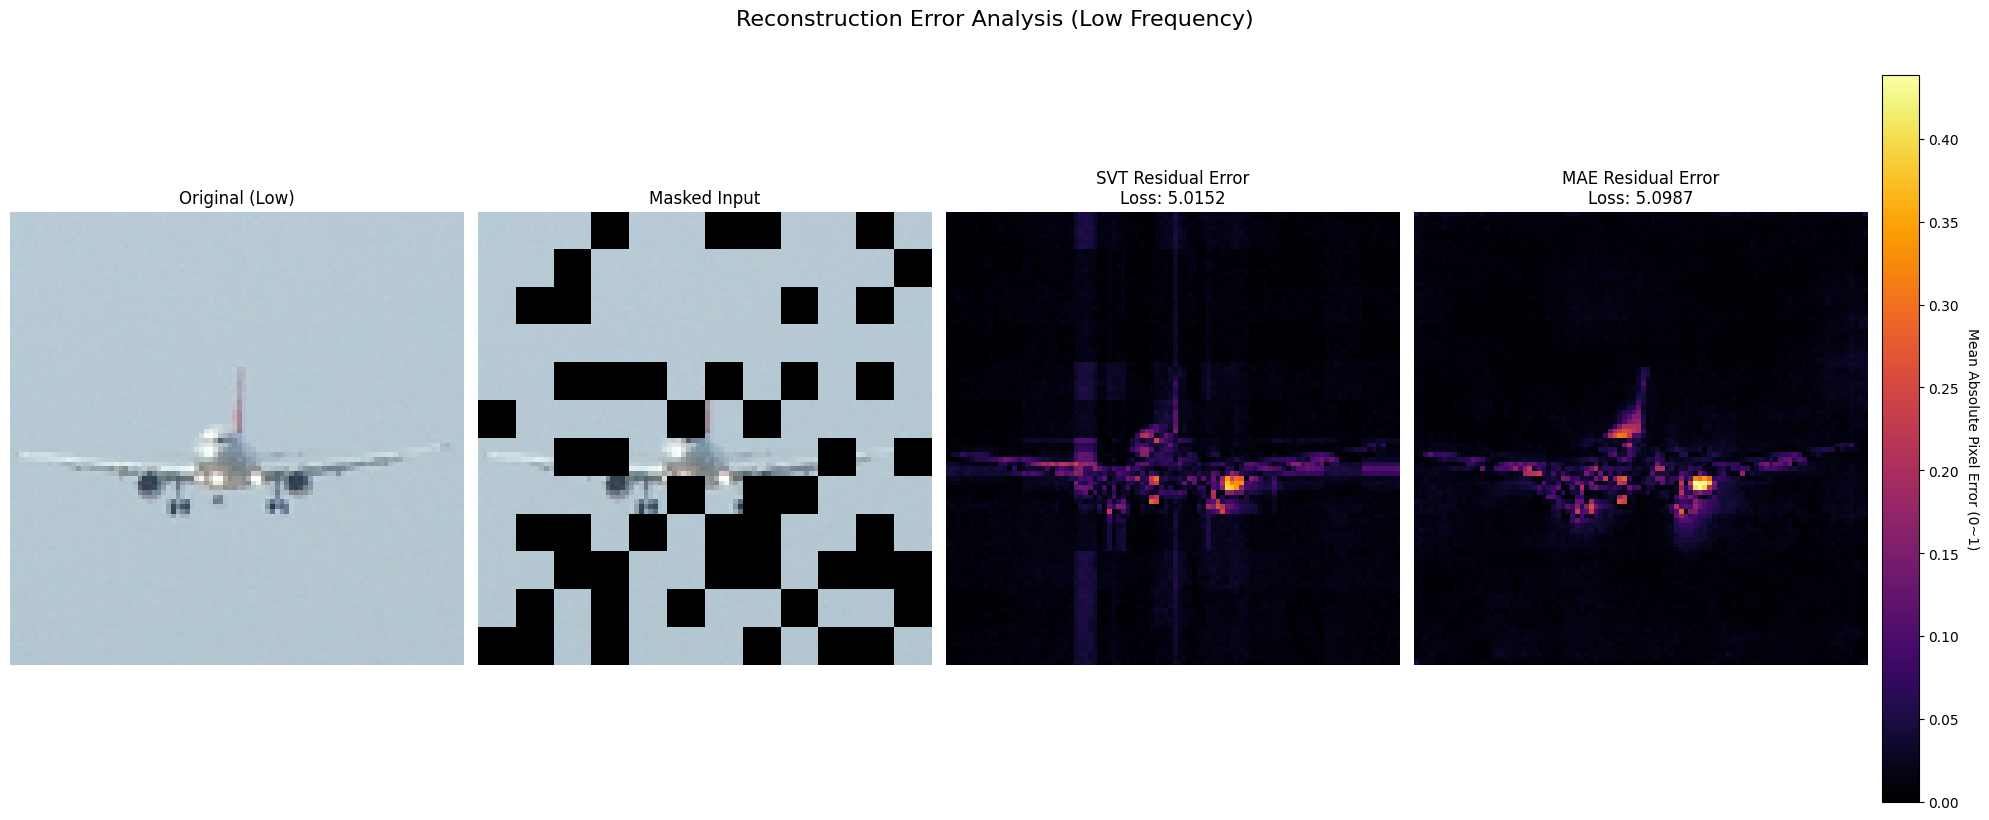

[High Freq Image Results]
  SVT Frobenius Loss: 25.6480
  MAE Frobenius Loss: 22.3044


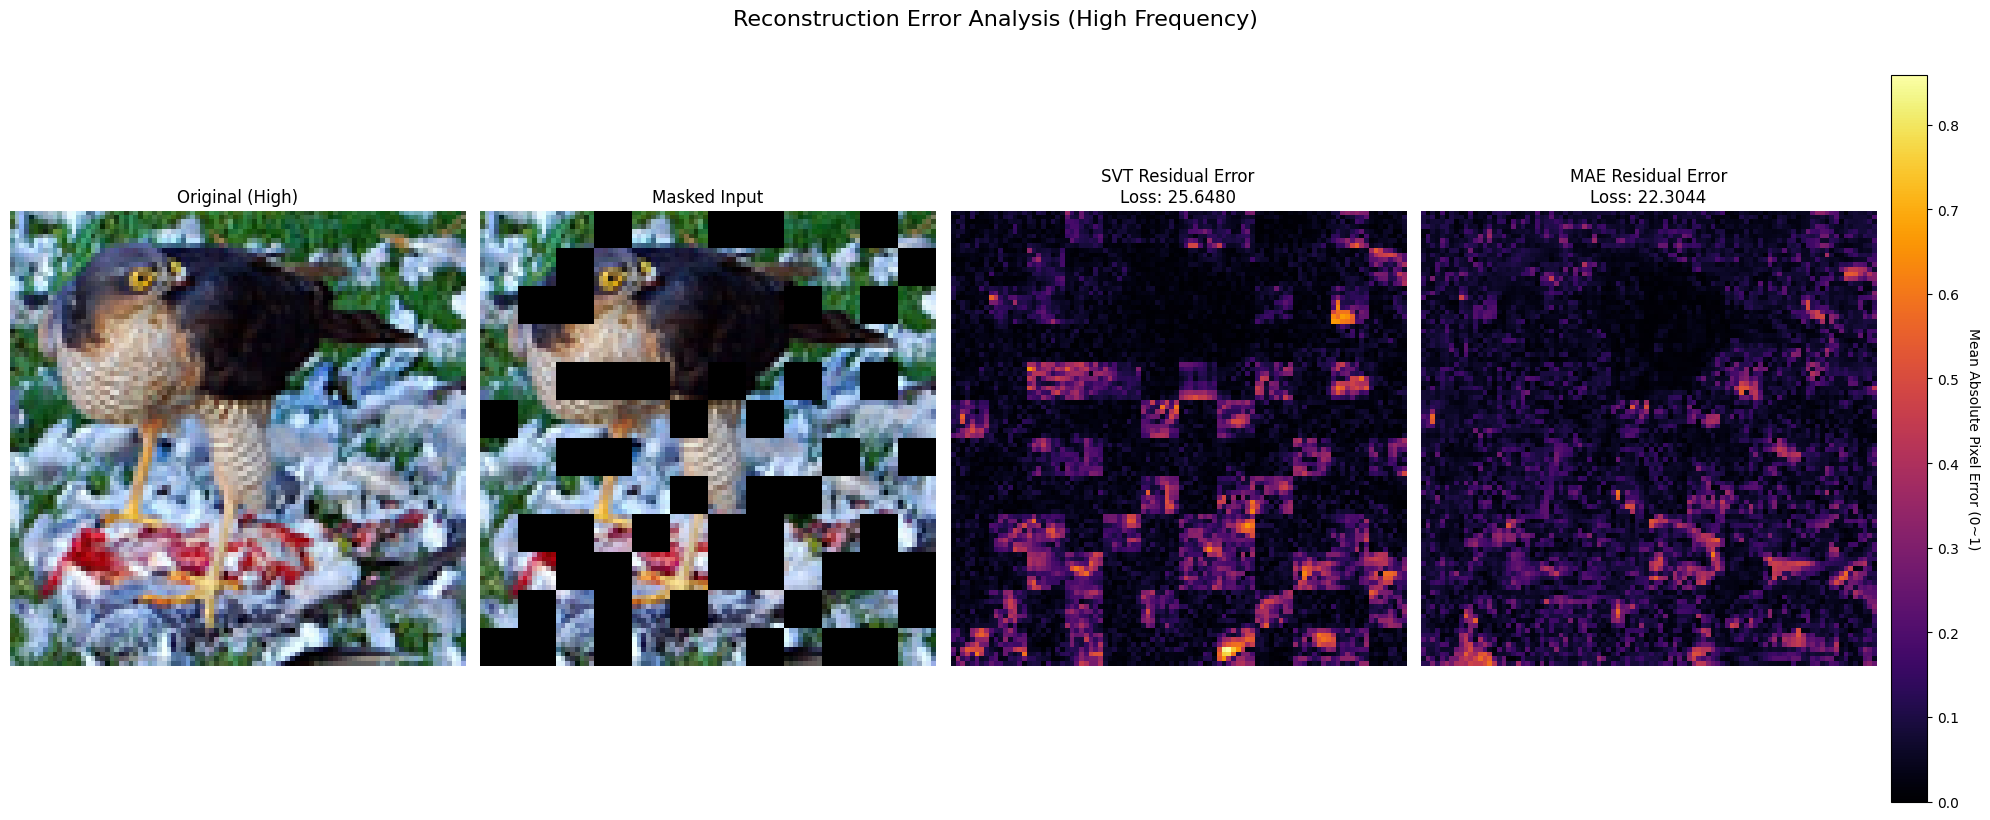

In [47]:
def evaluate_reconstruction_loss(image_idx, title_prefix):
    # 1. 準備資料
    orig_img, _ = dataset_scan[image_idx] # (C, H, W)
    C, H, W = orig_img.shape

    # Generate Mask (Same logic as before to ensure fair comparison)
    patch_size = 8
    # mask 邏輯要跟前面保持完全一致
    mask_ratio = 50 / (12*12)
    num_h = H // patch_size
    num_w = W // patch_size
    num_patches = num_h * num_w
    num_mask = int(mask_ratio * num_patches)
    if num_mask == 0: num_mask = 30

    g_cpu = torch.Generator()
    g_cpu.manual_seed(42)
    mask_idx = torch.randperm(num_patches, generator=g_cpu)[:num_mask]
    mask = torch.ones(num_patches)
    mask[mask_idx] = 0
    mask = mask.reshape(num_h, num_w)

    mask_pixels = mask.repeat_interleave(patch_size, 0).repeat_interleave(patch_size, 1)
    mask_pixels = mask_pixels.unsqueeze(0) # (1, H, W)

    masked_img = orig_img * mask_pixels

    # 2. SVT Reconstruction
    # (iters=500, tau=0.5)
    svt_recon, _, _ = reconstruct_rgb(masked_img, mask_pixels, num_iters=500, tau=0.5)

    # 3. MAE Reconstruction
    mae.eval()
    with torch.no_grad():
        mae_input = masked_img.unsqueeze(0).to(device)
        mask_input = mask_pixels.unsqueeze(0).to(device)
        mae_out = mae(mae_input, mask_input)
        mae_recon = mae_out[0].cpu()

    # 4. Calculate Frobenius Loss
    # Error tensor
    diff_svt = svt_recon - orig_img
    diff_mae = mae_recon - orig_img

    # Frobenius Norm: sqrt(sum(abs(x)**2))
    loss_svt = torch.norm(diff_svt, p='fro').item()
    loss_mae = torch.norm(diff_mae, p='fro').item()

    print(f"[{title_prefix} Freq Image Results]")
    print(f"  SVT Frobenius Loss: {loss_svt:.4f}")
    print(f"  MAE Frobenius Loss: {loss_mae:.4f}")

    # 5. Visualization of Residuals (Error Heatmap)
    # 使用 gridspec_kw 來預留 colorbar 的空間
    # width_ratios: 前4個是圖 (各佔1份), 最後1個是 colorbar (佔0.08份)
    fig, axs = plt.subplots(1, 5, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.08]})

    # Show difference magnitude (mean over channels)
    diff_svt_map = torch.mean(torch.abs(diff_svt), dim=0).numpy()
    diff_mae_map = torch.mean(torch.abs(diff_mae), dim=0).numpy()

    # 1. Original
    axs[0].imshow(orig_img.permute(1,2,0))
    axs[0].set_title(f"Original ({title_prefix})")
    axs[0].axis('off')

    # 2. Masked Input
    axs[1].imshow(masked_img.permute(1,2,0))
    axs[1].set_title("Masked Input")
    axs[1].axis('off')

    # vmax
    vmax = max(diff_svt_map.max(), diff_mae_map.max())

    # 3. SVT Residual
    im1 = axs[2].imshow(diff_svt_map, cmap='inferno', vmin=0, vmax=vmax)
    axs[2].set_title(f"SVT Residual Error\nLoss: {loss_svt:.4f}")
    axs[2].axis('off')

    # 4. MAE Residual
    im2 = axs[3].imshow(diff_mae_map, cmap='inferno', vmin=0, vmax=vmax)
    axs[3].set_title(f"MAE Residual Error\nLoss: {loss_mae:.4f}")
    axs[3].axis('off')

    # 5. Independent Colorbar
    cbar = fig.colorbar(im2, cax=axs[4])
    cbar.set_label('Mean Absolute Pixel Error (0~1)', rotation=270, labelpad=15)

    plt.suptitle(f"Reconstruction Error Analysis ({title_prefix} Frequency)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nCalculating Reconstruction Loss (Frobenius Norm)...")
evaluate_reconstruction_loss(low_freq_idx, "Low")
evaluate_reconstruction_loss(high_freq_idx, "High")






Calculating Reconstruction Loss (Frobenius Norm)...
[Low Freq Image Results]
  SVT Frobenius Loss: 5.0152
  MAE Frobenius Loss: 5.0987


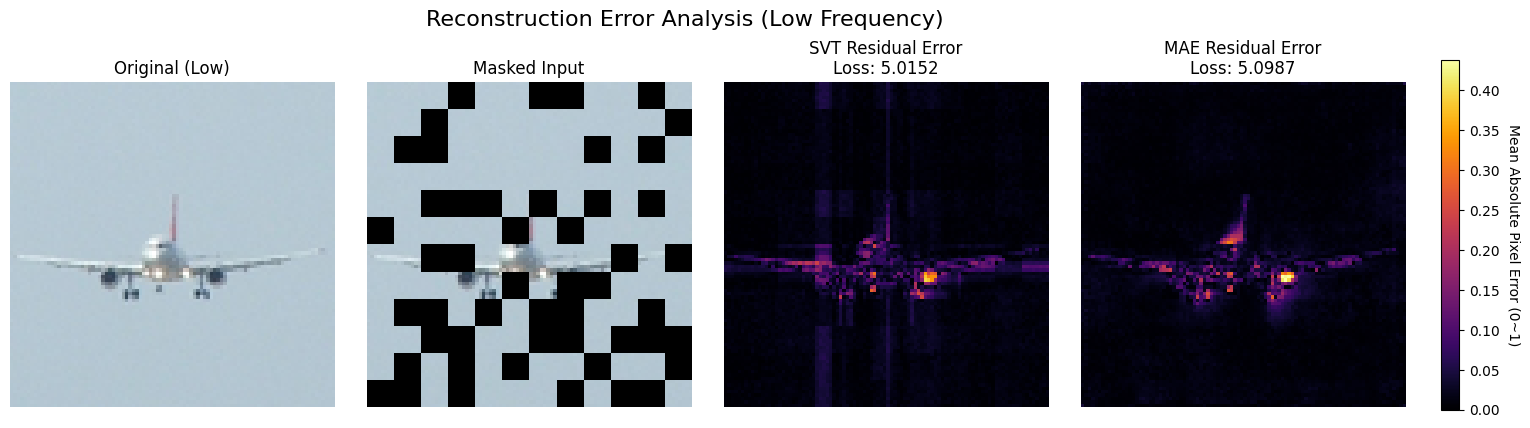

[High Freq Image Results]
  SVT Frobenius Loss: 25.6480
  MAE Frobenius Loss: 22.3044


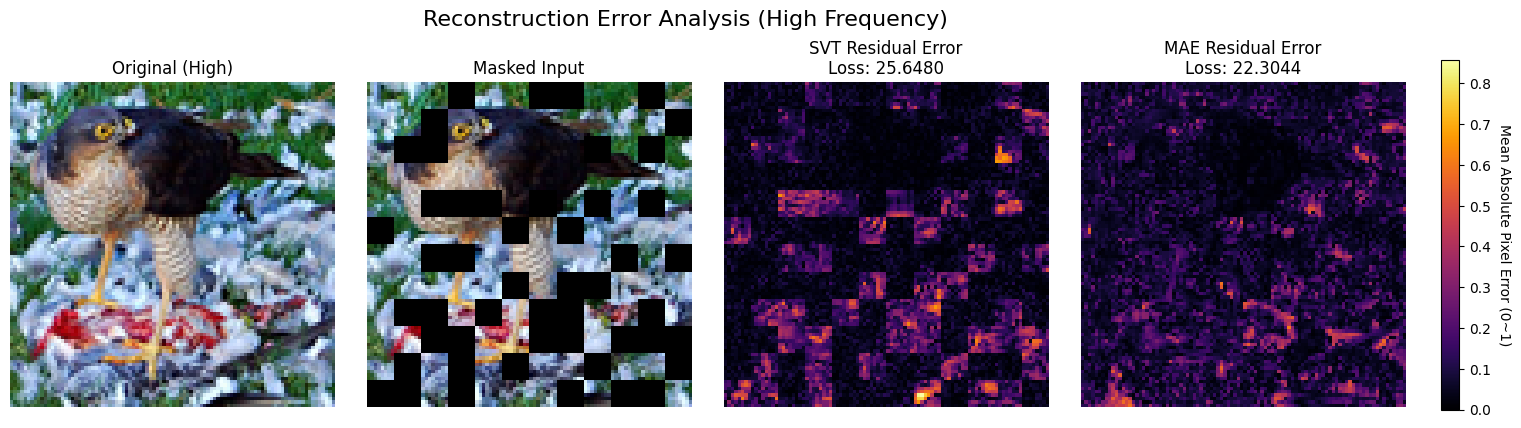

In [59]:
def evaluate_reconstruction_loss(image_idx, title_prefix):
    # 1. 準備資料
    orig_img, _ = dataset_scan[image_idx] # (C, H, W)
    C, H, W = orig_img.shape

    # Generate Mask (Same logic as before to ensure fair comparison)
    patch_size = 8
    # mask 邏輯要跟前面保持完全一致
    mask_ratio = 50 / (12*12)
    num_h = H // patch_size
    num_w = W // patch_size
    num_patches = num_h * num_w
    num_mask = int(mask_ratio * num_patches)
    if num_mask == 0: num_mask = 30

    g_cpu = torch.Generator()
    g_cpu.manual_seed(42)
    mask_idx = torch.randperm(num_patches, generator=g_cpu)[:num_mask]
    mask = torch.ones(num_patches)
    mask[mask_idx] = 0
    mask = mask.reshape(num_h, num_w)

    mask_pixels = mask.repeat_interleave(patch_size, 0).repeat_interleave(patch_size, 1)
    mask_pixels = mask_pixels.unsqueeze(0) # (1, H, W)

    masked_img = orig_img * mask_pixels

    # 2. SVT Reconstruction
    # (iters=500, tau=0.5)
    svt_recon, _, _ = reconstruct_rgb(masked_img, mask_pixels, num_iters=500, tau=0.5)

    # 3. MAE Reconstruction
    mae.eval()
    with torch.no_grad():
        mae_input = masked_img.unsqueeze(0).to(device)
        mask_input = mask_pixels.unsqueeze(0).to(device)
        mae_out = mae(mae_input, mask_input)
        mae_recon = mae_out[0].cpu()

    # 4. Calculate Frobenius Loss
    # Error tensor
    diff_svt = svt_recon - orig_img
    diff_mae = mae_recon - orig_img

    # Frobenius Norm: sqrt(sum(abs(x)**2))
    loss_svt = torch.norm(diff_svt, p='fro').item()
    loss_mae = torch.norm(diff_mae, p='fro').item()

    print(f"[{title_prefix} Freq Image Results]")
    print(f"  SVT Frobenius Loss: {loss_svt:.4f}")
    print(f"  MAE Frobenius Loss: {loss_mae:.4f}")

    # 5. Visualization of Residuals (Error Heatmap)
    # 回到 4 個 subplot，colorbar 另外處理
    fig, axs = plt.subplots(1, 4, figsize=(18, 5))

    # Show difference magnitude (mean over channels)
    diff_svt_map = torch.mean(torch.abs(diff_svt), dim=0).numpy()
    diff_mae_map = torch.mean(torch.abs(diff_mae), dim=0).numpy()

    # 1. Original
    axs[0].imshow(orig_img.permute(1,2,0))
    axs[0].set_title(f"Original ({title_prefix})")
    axs[0].axis('off')

    # 2. Masked Input
    axs[1].imshow(masked_img.permute(1,2,0))
    axs[1].set_title("Masked Input")
    axs[1].axis('off')

    # vmax
    vmax = max(diff_svt_map.max(), diff_mae_map.max())

    # 3. SVT Residual
    im1 = axs[2].imshow(diff_svt_map, cmap='inferno', vmin=0, vmax=vmax)
    axs[2].set_title(f"SVT Residual Error\nLoss: {loss_svt:.4f}")
    axs[2].axis('off')

    # 4. MAE Residual
    im2 = axs[3].imshow(diff_mae_map, cmap='inferno', vmin=0, vmax=vmax)
    axs[3].set_title(f"MAE Residual Error\nLoss: {loss_mae:.4f}")
    axs[3].axis('off')

    # 5. Global Colorbar (Manual Positioning)
    # 這樣保證前四張圖大小絕對一致，不會被 colorbar 擠壓
    # [left, bottom, width, height]
    # 根據 figsize=(18, 5) 調整
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])

    cbar = fig.colorbar(im2, cax=cbar_ax)
    cbar.set_label('Mean Absolute Pixel Error (0~1)', rotation=270, labelpad=15)

    plt.suptitle(f"Reconstruction Error Analysis ({title_prefix} Frequency)", fontsize=16, y=0.95)
    plt.subplots_adjust(top=0.85, right=0.9, wspace=0.1)
    plt.show()

print("\nCalculating Reconstruction Loss (Frobenius Norm)...")
evaluate_reconstruction_loss(low_freq_idx, "Low")
evaluate_reconstruction_loss(high_freq_idx, "High")



